# Build a `Scene` from other elements

A scene is a composition of three elements:
- A pointsource (`target`)
- A continuum flat background  (`background`)
- A structured background (`host`).

`slicersim.Scene` takes as input these three elements, but they could be left as _None_, resulting to a corresponding null spectrum (np.zeros).

**In that example, we will build a type Ia Supernovae scene that has no host background but zodiacal light**

See examples on how to build a supernovae and a background zodi on dedicated notebooks

In [1]:
from slicersim.scene import pointsource

/Users/griffin/PycharmProjects/twins_embedding/twins_embedding.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
parameters = dict(redshift=0.2, c=0.1, x1=-1) # store true values
model_func = pointsource.get_saltmodel_flux

In [3]:
position = (-0.4, 2) # position in the slicer

In [4]:
supernovae = pointsource.PointSource(model_func=model_func, 
                                    position=position, 
                                    meta=parameters)

In [5]:
supernovae._parse_model_kwargs_()

{'beta': 3.15,
 'alpha': -0.14,
 'c': 0.1,
 'x1': -1,
 'cosmo': FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897),
 'source': 'salt2-extended',
 'MBmax': -19.3,
 'redshift': 0.2,
 'abmag': None}

## Twins Embedding

In [6]:
twins_embedding_parameters = dict(redshift=0.2, magnitude=0., color=0.1, coordinates=[0., -1., 0.])
twins_embedding_supernova = pointsource.PointSource(model_func=pointsource.get_twins_embedding_flux,
                                                    position=position,
                                                    meta=twins_embedding_parameters)

In [7]:
twins_embedding_supernova._parse_model_kwargs_()

{'cosmo': FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897),
 'coordinates': [0.0, -1.0, 0.0],
 'color': 0.1,
 'magnitude': 0.0,
 'redshift': 0.2}

## A Zodiacal background

In [8]:
from slicersim.scene import background
parameters = {"name": "zodi"}
model_func = background.get_background_model_func("zodi")

In [9]:
bkgd = background.Background(model_func=model_func)

## and build the Scene

In [10]:
from slicersim.scene import Scene

In [11]:
sc = Scene(target=supernovae, background=bkgd)

so far the supernovae has no phase set. So let's do that first

In [12]:
sc.update(target__phase=-1, target__redshift=0.5) # "__" is parsed as "." as in django

In [13]:
sc.meta

{'target': {'redshift': 0.5,
  'c': 0.1,
  'x1': -1,
  'position': (-0.4, 2),
  'phase': -1},
 'background': {},
 'host': None}

In [14]:
sc2 = Scene(target=twins_embedding_supernova, background=bkgd)
sc2.update(target__phase=-1., target__redshift=0.5)
sc2.meta

{'target': {'redshift': 0.5,
  'magnitude': 0.0,
  'color': 0.1,
  'coordinates': [0.0, -1.0, 0.0],
  'position': (-0.4, 2),
  'phase': -1.0},
 'background': {},
 'host': None}

### to get a flux, need a phase and a wavelength

But those could be set as config parameters

In [15]:
import numpy as np
lbda = np.linspace(3_300, 17_000, 500)

In [16]:
lbda, fluxes = sc.get_stacked_spectra(lbda)
lbda2, fluxes2 = sc2.get_stacked_spectra(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

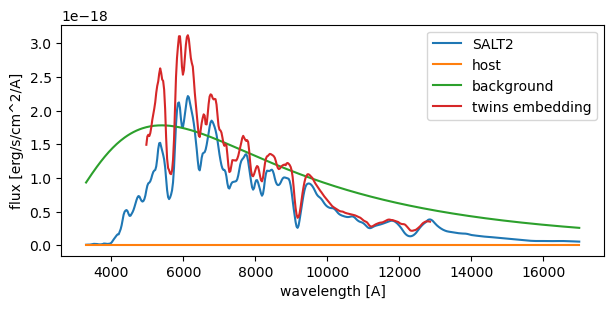

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, fluxes[0], label="SALT2")
ax.plot(lbda, fluxes[1], label="host")
ax.plot(lbda, fluxes[2], label="background")

ax.plot(lbda, fluxes2[0], label="twins embedding")

ax.legend()
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Load Supernovae from a config file

You may want to set the model and position parameters in a config dictionary. 

Just use the `.from_config()` to load a supernovae instance from this configuration

In [18]:
from slicersim import iotools
scene_config = iotools.get_config()["scene"]
scene_config

{'point_source': {'name': 'SN Ia',
  'source': 'salt2-extended',
  'redshift': 1.5,
  'phase': 0,
  'MBmax': -19.3,
  'position': [1, 0.5],
  'c': 0,
  'x1': 0},
 'background': {'name': 'zodi', 'model': 'Aldering01.BB5800', 'scale': 2.0}}

In [19]:
scene = Scene.from_config(scene_config)

In [20]:
lbda, fluxes = scene.get_stacked_spectra(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

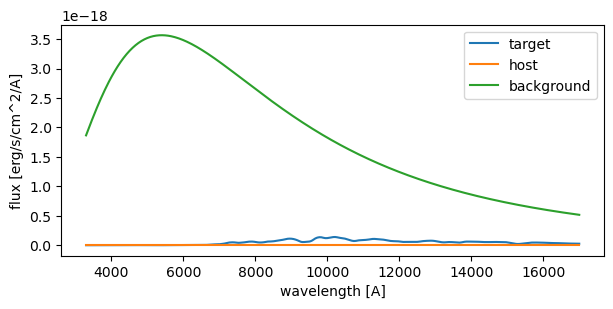

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, fluxes[0], label="target")
ax.plot(lbda, fluxes[1], label="host")
ax.plot(lbda, fluxes[2], label="background")

ax.legend()
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")